<a href="https://colab.research.google.com/github/huonggnguyen-source/AIHC-5020/blob/main/homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.cloud import storage
from google.auth.credentials import AnonymousCredentials

# Instantiate a storage client with AnonymousCredentials
client = storage.Client(credentials=AnonymousCredentials())

# Get the public bucket
bucket_name = 'cloud-samples-data'
bucket = client.bucket(bucket_name)

# List blobs under the 'ml-engine' prefix to find adult.data.csv
blobs = client.list_blobs(bucket_name, prefix='ml-engine')

for blob in blobs:
    if 'adult.data.csv' in blob.name:
        print("Found blob name:", blob.name)
        blob_name = blob.name

Found blob name: ml-engine/census/data/adult.data.csv


In [2]:
import io
import pandas as pd
from google.cloud import storage

def load_csv_blob(blob_name, bucket, column_names=[]):
    """

    """
    # Create the blob object using the bucket and blob name
    blob = bucket.blob(blob_name)

    # Download blob contents as text
    content = blob.download_as_text()

    if column_names:
        df = pd.read_csv(io.StringIO(content), names=column_names, header=None)
    else:
        df = pd.read_csv(io.StringIO(content))

    return df

In [4]:
COLUMN_NAMES = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income_bracket'
]

blob_name = 'ml-engine/census/data/adult.data.csv'

df = load_csv_blob(blob_name, bucket, column_names=COLUMN_NAMES)

# Show the first 5 rows
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
# Problem 2: Querying from BigQuery#


In [3]:
from google.colab import auth
from google.cloud import bigquery
PROJECT_ID = 'charged-hub-509718-t4'

auth.authenticate_user(project_id=PROJECT_ID)
client = bigquery.Client(project=PROJECT_ID)

sql_query = """
SELECT
    date,
    new_confirmed,
    new_deceased
FROM
    `bigquery-public-data.covid19_open_data.covid19_open_data`
WHERE
    country_name = 'Mexico'
    AND date BETWEEN '2021-01-01' AND '2021-12-31'
ORDER BY
    date ASC
"""

df_mexico = client.query(sql_query).to_dataframe()

print(f"Total rows: {len(df_mexico)}")
df_mexico.head()

Total rows: 911770


,date,new_confirmed,new_deceased
0,2021-01-01,<NA>,<NA>
1,2021-01-01,<NA>,<NA>
2,2021-01-01,<NA>,<NA>
3,2021-01-01,<NA>,<NA>
4,2021-01-01,<NA>,<NA>


In [4]:
#Problem 3: Aggregating and Visualizing the Data

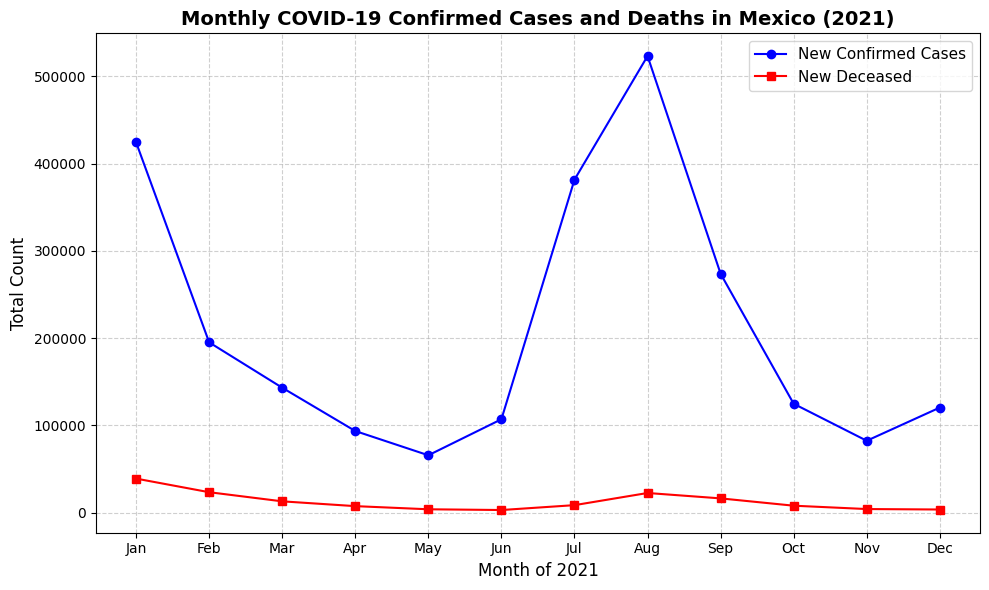

    month  new_confirmed  new_deceased
0       1         424394         39156
1       2         195234         23558
2       3         143254         13099
3       4          93647          7606
4       5          65871          4004
5       6         107135          3152
6       7         381611          8735
7       8         523222         22656
8       9         273774         16481
9      10         124864          8110
10     11          82496          4268
11     12         120519          3745


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df_mexico['month'] = df_mexico['date'].apply(lambda dt: dt.month)

monthly_covid_df = df_mexico.groupby('month')[['new_confirmed', 'new_deceased']].sum().reset_index()

plt.figure(figsize=(10, 6))

plt.plot(monthly_covid_df['month'], monthly_covid_df['new_confirmed'], marker='o', color='blue', label='New Confirmed Cases')
plt.plot(monthly_covid_df['month'], monthly_covid_df['new_deceased'], marker='s', color='red', label='New Deceased')

plt.title('Monthly COVID-19 Confirmed Cases and Deaths in Mexico (2021)', fontsize=14, fontweight='bold')
plt.xlabel('Month of 2021', fontsize=12)
plt.ylabel('Total Count', fontsize=12)

plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


print(monthly_covid_df)